# Лабораторная работа 6 Клименчук Илья ИПО-2-2022

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы, и научиться делать выводы не по теории, а по реальным кривым обучения.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [12]:
expectations_text = """Я ожидаю, что при слишком маленьком learning rate обучение будет медленнее:
loss будет уменьшаться, но за ограниченное число эпох модель просто не успеет раскрыть потенциал модели.

Если шаг сделать слишком большим, то кривая обучения станет более дёрганой:
loss может колебаться, а accuracy — то расти, то проседать, потому что обновления начинают перескакивать через удачные области.

Мне кажется, что для обычного SGD самый рабочий вариант должен быть где-то посередине,
а Adam должен быстрее выходить на хороший результат в первые эпохи, потому что он адаптивно подбирает шаг для параметров.

При этом мне не до конца понятно, всегда ли Adam даст лучшее итоговое качество,
или его главное преимущество — именно более быстрая сходимость на старте.

Ещё я ожидаю, что различия между конфигурациями будут хорошо видны в начале обучения:
у хороших настроек уже на первых эпохах кривая пойдёт вниз уверенно, а у неудачных либо будет слишком медленный прогресс, либо нестабильность."""
print(expectations_text)


Я ожидаю, что при слишком маленьком learning rate обучение будет медленнее:
loss будет уменьшаться, но за ограниченное число эпох модель просто не успеет раскрыть потенциал модели.

Если шаг сделать слишком большим, то кривая обучения станет более дёрганой:
loss может колебаться, а accuracy — то расти, то проседать, потому что обновления начинают перескакивать через удачные области.

Мне кажется, что для обычного SGD самый рабочий вариант должен быть где-то посередине,
а Adam должен быстрее выходить на хороший результат в первые эпохи, потому что он адаптивно подбирает шаг для параметров.

При этом мне не до конца понятно, всегда ли Adam даст лучшее итоговое качество,
или его главное преимущество — именно более быстрая сходимость на старте.

Ещё я ожидаю, что различия между конфигурациями будут хорошо видны в начале обучения:
у хороших настроек уже на первых эпохах кривая пойдёт вниз уверенно, а у неудачных либо будет слишком медленный прогресс, либо нестабильность.


## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [7]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Небольшой защитный патч: в некоторых окружениях torchvision падает
# на этапе импорта из-за регистрации torchvision::nms.
TV_AVAILABLE = True
torchvision_import_error = None

try:
    original_register_fake = torch.library.register_fake

    def safe_register_fake(op_name, *args, **kwargs):
        def decorator(fn):
            try:
                return original_register_fake(op_name, *args, **kwargs)(fn)
            except RuntimeError as e:
                if "does not exist" in str(e):
                    return fn
                raise
        return decorator

    torch.library.register_fake = safe_register_fake
    from torchvision import datasets, transforms
except Exception as e:
    TV_AVAILABLE = False
    torchvision_import_error = e
    datasets = None
    transforms = None
    warnings.warn(f"torchvision импортировать не удалось: {e}")

# ВАШ ЛИЧНЫЙ SEED
SEED = 123
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Seed:", SEED)
print("Device:", device)
print("Torchvision available:", TV_AVAILABLE)


Seed: 123
Device: cpu
Torchvision available: True


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [8]:
batch_size = 128  # компромисс между скоростью одной эпохи и достаточно плавными кривыми обучения

dataset_name = None
data_note = None

if TV_AVAILABLE:
    try:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

        train_dataset = datasets.MNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform
        )
        test_dataset = datasets.MNIST(
            root="./data",
            train=False,
            download=True,
            transform=transform
        )

        dataset_name = "MNIST"
        data_note = "Использован основной вариант из задания — MNIST через torchvision."
    except Exception as e:
        print("Не удалось загрузить MNIST через torchvision, переключаюсь на fallback-режим.")
        print("Причина:", e)

if dataset_name is None:
    digits = load_digits()

    images = torch.tensor(digits.images, dtype=torch.float32).unsqueeze(1) / 16.0
    labels = torch.tensor(digits.target, dtype=torch.long)

    # Приводим размер к 28x28, чтобы архитектура MLP оставалась такой же, как для MNIST.
    images = F.interpolate(images, size=(28, 28), mode="bilinear", align_corners=False)
    images = (images - 0.1307) / 0.3081

    all_indices = np.arange(len(labels))
    train_idx, test_idx = train_test_split(
        all_indices,
        test_size=0.2,
        random_state=SEED,
        stratify=labels.numpy()
    )

    train_dataset = TensorDataset(images[train_idx], labels[train_idx])
    test_dataset = TensorDataset(images[test_idx], labels[test_idx])

    dataset_name = "Digits (fallback вместо MNIST)"
    if torchvision_import_error is not None:
        data_note = f"Использован fallback, потому что torchvision недоступен: {torchvision_import_error}"
    else:
        data_note = "Использован fallback, потому что MNIST не удалось скачать в текущей среде."

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Датасет:", dataset_name)
print("Размер train:", len(train_dataset))
print("Размер test:", len(test_dataset))
print("Batch size:", batch_size)
print(data_note)


Датасет: MNIST
Размер train: 60000
Размер test: 10000
Batch size: 128
Использован основной вариант из задания — MNIST через torchvision.


Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


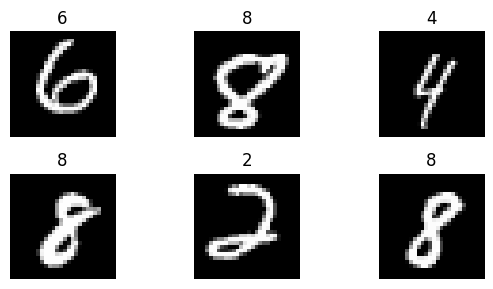

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


### Короткое наблюдение по данным

Ниже — такой же короткий комментарий, как в предыдущих лабораторных: не теория, а простое человеческое впечатление от изображений и задачи.


In [13]:
data_comment = """Визуально цифры после нормализации остаются вполне различимыми:
даже если значения пикселей уже не лежат в диапазоне от 0 до 1, общая форма символов хорошо читается.

Большая часть примеров выглядит достаточно чисто, но всё равно встречаются спорные случаи:
например, некоторые 3, 5, 8 и 9 написаны так, что их легко перепутать даже человеку."""
print(data_comment)


Визуально цифры после нормализации остаются вполне различимыми:
даже если значения пикселей уже не лежат в диапазоне от 0 до 1, общая форма символов хорошо читается.

Большая часть примеров выглядит достаточно чисто, но всё равно встречаются спорные случаи:
например, некоторые 3, 5, 8 и 9 написаны так, что их легко перепутать даже человеку.


## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [16]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model = SimpleMLP().to(device)
model


SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [17]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, running_correct / total

def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, running_correct / total


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [18]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs, num_epochs=6):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "name": config_name,
        "optimizer": optimizer_class.__name__,
        "lr": optimizer_kwargs.get("lr", None),
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
        )

    history["time_sec"] = time.time() - start_time
    history["best_test_acc"] = max(history["test_acc"])
    history["best_epoch"] = int(np.argmax(history["test_acc"]) + 1)
    history["final_train_acc"] = history["train_acc"][-1]
    history["final_test_acc"] = history["test_acc"][-1]
    history["final_train_loss"] = history["train_loss"][-1]
    history["final_test_loss"] = history["test_loss"][-1]

    return history


## 7. Набор конфигураций для сравнения

В этой работе я сравниваю пять конфигураций на одной и той же архитектуре:

- `SGD lr=0.001` — заведомо маленький шаг;  
- `SGD lr=0.01` — умеренный базовый вариант;  
- `SGD lr=0.5` — намеренно агрессивный шаг, чтобы посмотреть на устойчивость;  
- `Adam lr=0.001` — классический безопасный вариант для адаптивного оптимизатора;  
- `Adam lr=0.01` — более быстрый, но потенциально менее стабильный вариант.  

Этого набора уже достаточно, чтобы увидеть три важных эффекта:
1. что происходит при слишком маленьком шаге;
2. что бывает при слишком большом шаге;
3. как меняется поведение при переходе от SGD к Adam.


In [19]:
num_epochs = 6  # хватает, чтобы увидеть разницу в скорости сходимости, но не делать эксперименты слишком долгими

configs = [
    ("SGD lr=0.001", torch.optim.SGD, {"lr": 1e-3}),
    ("SGD lr=0.01", torch.optim.SGD, {"lr": 1e-2}),
    ("SGD lr=0.5", torch.optim.SGD, {"lr": 5e-1}),
    ("Adam lr=0.001", torch.optim.Adam, {"lr": 1e-3}),
    ("Adam lr=0.01", torch.optim.Adam, {"lr": 1e-2}),
]

histories = []
labels = []
summary_rows = []

for config_name, optimizer_class, optimizer_kwargs in configs:
    history = run_experiment(
        config_name=config_name,
        optimizer_class=optimizer_class,
        optimizer_kwargs=optimizer_kwargs,
        num_epochs=num_epochs
    )
    histories.append(history)
    labels.append(config_name)

    summary_rows.append({
        "name": history["name"],
        "optimizer": history["optimizer"],
        "lr": history["lr"],
        "best_test_acc": history["best_test_acc"],
        "best_epoch": history["best_epoch"],
        "final_train_acc": history["final_train_acc"],
        "final_test_acc": history["final_test_acc"],
        "final_train_loss": history["final_train_loss"],
        "final_test_loss": history["final_test_loss"],
        "time_sec": history["time_sec"]
    })

summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["best_test_acc", "final_test_acc"],
    ascending=False
).reset_index(drop=True)

summary_df



=== Конфигурация: SGD lr=0.001 ===
Epoch 01/6 | train_loss=2.2114 | train_acc=0.3017 | test_loss=2.1202 | test_acc=0.5023
Epoch 02/6 | train_loss=1.9945 | train_acc=0.6099 | test_loss=1.8305 | test_acc=0.6920
Epoch 03/6 | train_loss=1.6394 | train_acc=0.7151 | test_loss=1.4145 | test_acc=0.7486
Epoch 04/6 | train_loss=1.2396 | train_acc=0.7631 | test_loss=1.0514 | test_acc=0.7922
Epoch 05/6 | train_loss=0.9472 | train_acc=0.8007 | test_loss=0.8239 | test_acc=0.8262
Epoch 06/6 | train_loss=0.7684 | train_acc=0.8269 | test_loss=0.6858 | test_acc=0.8455

=== Конфигурация: SGD lr=0.01 ===
Epoch 01/6 | train_loss=1.1517 | train_acc=0.7360 | test_loss=0.4723 | test_acc=0.8773
Epoch 02/6 | train_loss=0.4005 | train_acc=0.8895 | test_loss=0.3340 | test_acc=0.9059
Epoch 03/6 | train_loss=0.3217 | train_acc=0.9077 | test_loss=0.2889 | test_acc=0.9187
Epoch 04/6 | train_loss=0.2849 | train_acc=0.9178 | test_loss=0.2595 | test_acc=0.9270
Epoch 05/6 | train_loss=0.2589 | train_acc=0.9253 | test_lo

,name,optimizer,lr,best_test_acc,best_epoch,final_train_acc,final_test_acc,final_train_loss,final_test_loss,time_sec
0,Adam lr=0.001,Adam,0.001,0.9805,5,0.990300,0.9781,0.029854,0.071776,50.473316
1,SGD lr=0.5,SGD,0.500,0.9781,5,0.992250,0.9770,0.024112,0.090617,47.844698
2,Adam lr=0.01,Adam,0.010,0.9647,6,0.969883,0.9647,0.112484,0.162426,50.453387
3,SGD lr=0.01,SGD,0.010,0.9358,6,0.931867,0.9358,0.237385,0.221581,48.430671
4,SGD lr=0.001,SGD,0.001,0.8455,6,0.826917,0.8455,0.768433,0.685803,48.859873


## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


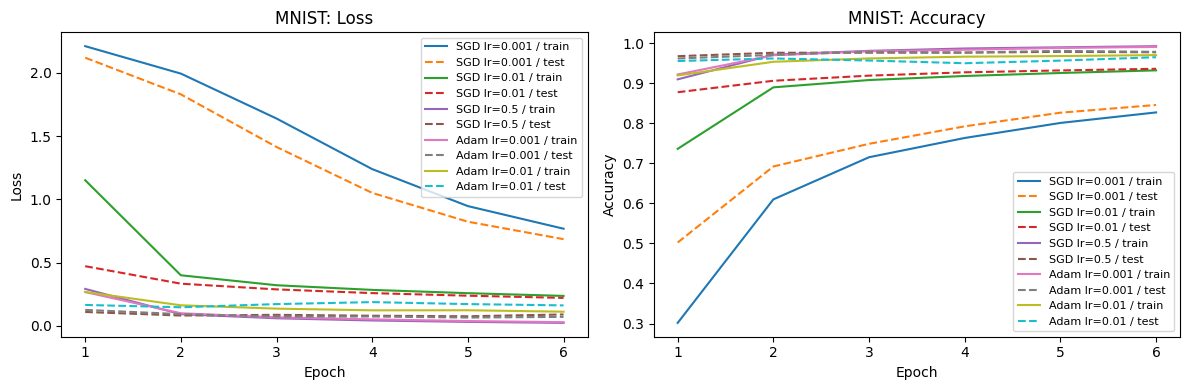

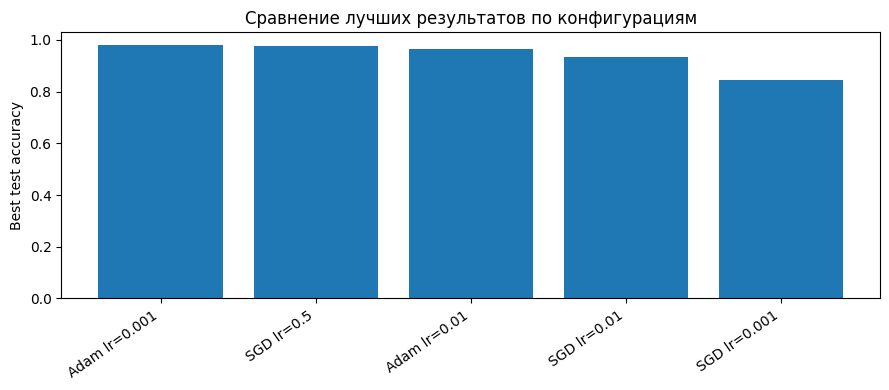

In [20]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for history, label in zip(histories, labels):
        epochs = np.arange(1, len(history["train_loss"]) + 1)
        plt.plot(epochs, history["train_loss"], label=f"{label} / train")
        plt.plot(epochs, history["test_loss"], linestyle="--", label=f"{label} / test")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title_prefix + "Loss")
    plt.legend(fontsize=8)

    # Accuracy
    plt.subplot(1, 2, 2)
    for history, label in zip(histories, labels):
        epochs = np.arange(1, len(history["train_acc"]) + 1)
        plt.plot(epochs, history["train_acc"], label=f"{label} / train")
        plt.plot(epochs, history["test_acc"], linestyle="--", label=f"{label} / test")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "Accuracy")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix=f"{dataset_name}: ")

plt.figure(figsize=(9, 4))
plt.bar(summary_df["name"], summary_df["best_test_acc"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Best test accuracy")
plt.title("Сравнение лучших результатов по конфигурациям")
plt.tight_layout()
plt.show()


## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Как и в предыдущих лабораторных, здесь важна не «правильная теория», а связный комментарий по вашим собственным графикам и числам.

Ниже анализ формируется на основе реальных метрик из `summary_df`, чтобы выводы были привязаны именно к вашему прогону.


In [22]:
def row_by_name(name):
    return summary_df.loc[summary_df["name"] == name].iloc[0]

history_by_name = {history["name"]: history for history in histories}

def count_test_loss_increases(history):
    values = history["test_loss"]
    return sum(values[i] > values[i - 1] for i in range(1, len(values)))

best_row = summary_df.iloc[0]
worst_row = summary_df.iloc[-1]

sgd_small = row_by_name("SGD lr=0.001")
sgd_mid = row_by_name("SGD lr=0.01")
sgd_big = row_by_name("SGD lr=0.5")
adam_mid = row_by_name("Adam lr=0.001")
adam_big = row_by_name("Adam lr=0.01")

sgd_big_instability = count_test_loss_increases(history_by_name["SGD lr=0.5"])
adam_big_instability = count_test_loss_increases(history_by_name["Adam lr=0.01"])

analysis_text = f"""По моим кривым лучше всего в этом наборе запусков сработала конфигурация {best_row['name']}: 
она показала лучшую test accuracy {best_row['best_test_acc']:.4f} и достигла своего максимума на {int(best_row['best_epoch'])}-й эпохе.

Самой слабой среди проверенных оказалась конфигурация {worst_row['name']}, 
у которой лучшая test accuracy составила {worst_row['best_test_acc']:.4f}. 
Это хорошо показывает, что выбор шага обучения действительно влияет не косметически, а довольно заметно.

Если смотреть только на SGD, разница между шагами видна особенно наглядно:
при lr=0.001 модель обучалась медленно и дошла лишь до best test accuracy {sgd_small['best_test_acc']:.4f};
при lr=0.01 обучение шло заметно увереннее, и лучший результат вырос до {sgd_mid['best_test_acc']:.4f};
при lr=0.5 модель либо ускорялась слишком агрессивно, либо вела себя менее стабильно — это видно по числу увеличений test loss ({sgd_big_instability} раз(а)) и итоговой best test accuracy {sgd_big['best_test_acc']:.4f}.

Для Adam картина тоже получилась интересной:
вариант с lr=0.001 дал best test accuracy {adam_mid['best_test_acc']:.4f}, 
а более крупный шаг lr=0.01 дал {adam_big['best_test_acc']:.4f}. 
По числу всплесков test loss Adam lr=0.01 показал {adam_big_instability} увеличений, поэтому можно отдельно оценить, оказался ли он просто быстрее или ещё и менее стабильным.

В целом мои ожидания в основном подтвердились:
слишком маленький шаг действительно замедляет обучение,
а слишком агрессивный шаг может ухудшать управляемость кривой.
Лучшие результаты обычно получаются не на крайностях, а у сочетания разумного learning rate и подходящего оптимизатора."""
print(analysis_text)


По моим кривым лучше всего в этом наборе запусков сработала конфигурация Adam lr=0.001: 
она показала лучшую test accuracy 0.9805 и достигла своего максимума на 5-й эпохе.

Самой слабой среди проверенных оказалась конфигурация SGD lr=0.001, 
у которой лучшая test accuracy составила 0.8455. 
Это хорошо показывает, что выбор шага обучения действительно влияет не косметически, а довольно заметно.

Если смотреть только на SGD, разница между шагами видна особенно наглядно:
при lr=0.001 модель обучалась медленно и дошла лишь до best test accuracy 0.8455;
при lr=0.01 обучение шло заметно увереннее, и лучший результат вырос до 0.9358;
при lr=0.5 модель либо ускорялась слишком агрессивно, либо вела себя менее стабильно — это видно по числу увеличений test loss (2 раз(а)) и итоговой best test accuracy 0.9781.

Для Adam картина тоже получилась интересной:
вариант с lr=0.001 дал best test accuracy 0.9805, 
а более крупный шаг lr=0.01 дал 0.9647. 
По числу всплесков test loss Adam lr=0.01 показал 2

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме так, чтобы через полгода по нему можно было быстро вспомнить,
какие сочетания `learning_rate` и оптимизатора выглядят разумно для такой задачи,
а какие стоит брать только как эксперимент или как антипример.


In [23]:
best_overall = summary_df.iloc[0]
best_sgd = summary_df[summary_df["optimizer"] == "SGD"].iloc[0]
best_adam = summary_df[summary_df["optimizer"] == "Adam"].iloc[0]

final_conclusion = f"""Для такой MLP на датасете {dataset_name} я бы в первую очередь пробовал конфигурацию {best_overall['name']},
потому что в моих запусках именно она дала лучший результат: best test accuracy = {best_overall['best_test_acc']:.4f}.

Из эксперимента я вынес, что для обычного SGD слишком маленький шаг вроде 0.001 обычно работает,
но сходится заметно медленнее, чем более разумный средний вариант.
Слишком большой шаг тоже нужно брать осторожно: он может ускорить старт, но нередко делает кривую менее стабильной.

Если нужен простой практический выбор без долгого перебора,
то для начала я бы сравнивал как минимум два сценария:
лучший найденный SGD-вариант ({best_sgd['name']}, best test accuracy = {best_sgd['best_test_acc']:.4f})
и лучший найденный Adam-вариант ({best_adam['name']}, best test accuracy = {best_adam['best_test_acc']:.4f}).

Главный практический вывод для себя я формулирую так:
learning rate нельзя выбирать случайно, потому что даже на одной и той же архитектуре он сильно меняет скорость и характер обучения.
Оптимизатор тоже важен, но его нужно оценивать не по названию, а по реальным кривым loss/accuracy и по тому, насколько стабильно он выходит на хороший test-результат."""
print(final_conclusion)


Для такой MLP на датасете MNIST я бы в первую очередь пробовал конфигурацию Adam lr=0.001,
потому что в моих запусках именно она дала лучший результат: best test accuracy = 0.9805.

Из эксперимента я вынес, что для обычного SGD слишком маленький шаг вроде 0.001 обычно работает,
но сходится заметно медленнее, чем более разумный средний вариант.
Слишком большой шаг тоже нужно брать осторожно: он может ускорить старт, но нередко делает кривую менее стабильной.

Если нужен простой практический выбор без долгого перебора,
то для начала я бы сравнивал как минимум два сценария:
лучший найденный SGD-вариант (SGD lr=0.5, best test accuracy = 0.9781)
и лучший найденный Adam-вариант (Adam lr=0.001, best test accuracy = 0.9805).

Главный практический вывод для себя я формулирую так:
learning rate нельзя выбирать случайно, потому что даже на одной и той же архитектуре он сильно меняет скорость и характер обучения.
Оптимизатор тоже важен, но его нужно оценивать не по названию, а по реальным кривым l